In [1]:
import jax
import jax.numpy as jnp
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X, y = make_classification(n_samples=500, n_features=2, n_redundant=0, n_informative=1, 
                          n_clusters_per_class=1, random_state=14)

y = y[:,jnp.newaxis]

#X, X_test, y, y_test = train_test_split(X, y)

#sns.set_style('white')
#sns.scatterplot(X[:,0],X[:,1],hue=y.reshape(-1));

In [3]:
@jax.jit
def sigmoid(x):
    return 1 / (1 + jnp.exp(-x))

In [4]:
@jax.jit
def loss_fn(params, X, y):
    m = len(y)
    h = sigmoid(X.dot(params))
    epsilon = 1e-5
    loss = (1/m)*(((-y).T).dot(jnp.log(h + epsilon))-(((1 - y).T).dot(jnp.log(1 - h + epsilon))))
    loss = loss[0,0]
    return loss

def gradient_descent(params, X, y, lr, iterations):
    m = len(y)
    cost_history = jnp.zeros((iterations,1))
    
    for i in range(iterations):
        params = params - (lr/m)*(X.T.dot(sigmoid(X.dot(params) - y)))
        cost_history[i] = compute_cost(params, X, Y)
        
    return (cost_history, params)

In [5]:
def foward(X, params):
    return jnp.round(sigmoid(X.dot(params)))

In [6]:
grad_fn = jax.grad(loss_fn)

In [7]:
def update(params, grads):
    return jax.tree_multimap(lambda p, g: p - 0.05 * g, params, grads)

In [8]:
m = len(y)

X = jnp.hstack((jnp.ones((m,1)),X))
n = jnp.size(X,1)
params = jnp.zeros((n,1))

In [9]:
for i in range(1500):
    loss = loss_fn(params, X, y)
    if i%100 == 0:
        print('loss: ',loss)
    
    grads = grad_fn(params, X, y)
    params = update(params, grads)

loss:  0.69312716
loss:  0.26350892
loss:  0.19944835
loss:  0.17411326
loss:  0.16037959
loss:  0.15168436
loss:  0.14565068
loss:  0.14120513
loss:  0.13778898
loss:  0.1350813
loss:  0.13288352
loss:  0.13106592
loss:  0.12953973
loss:  0.12824206
loss:  0.12712702


In [10]:
print("Optimal Parameters are: \n", params, "\n")

Optimal Parameters are: 
 [[-0.66550833]
 [ 3.7322226 ]
 [ 0.03968403]] 



In [12]:
y_pred = foward(X, params)
score = float(sum(y_pred == y))/ float(len(y))

print('Score: ',score)

Score:  0.97


/home/alisson/.local/lib/python3.6/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


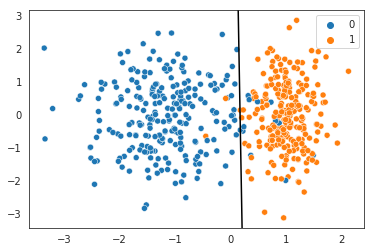

In [13]:
slope = -(params[1] / params[2])
intercept = -(params[0] / params[2])

sns.set_style('white')
sns.scatterplot(X[:,1],X[:,2],hue=y.reshape(-1));

ax = plt.gca()
ax.autoscale(False)
x_vals = jnp.array(ax.get_xlim())
y_vals = intercept + (slope * x_vals)
plt.plot(x_vals, y_vals, c="k");